# Cointegration Pairs Strategy — Research Notebook

Pair discovery, out-of-sample validation, walk-forward analysis, tearsheet,
and parameter sensitivity. Run top-to-bottom (`Kernel -> Restart & Run All`).

**Methodology in one paragraph.** The backtest runs over the full 2019–2023
window through an event-driven engine (point-in-time bars, next-bar fills,
commission + slippage). The strategy is dormant until `TRAIN_END`: on that
bar it screens pairs using only elapsed data — Engle–Granger on log prices
at p < 0.05 over the training window minus the final 3 months, then
re-qualification at p < 0.10 on those held-out 3 months. All trading and
all reported metrics are from bars **after** `TRAIN_END`, which the
discovery step never saw.

In [1]:
import sys; sys.path.insert(0, "..")
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint

from run import run_backtest
from backtester.data import fetch_prices
from strategies.pairs import CointegrationPairsStrategy, SECTORS
from backtester.metrics import (
    sharpe_ratio, sortino_ratio, max_drawdown,
    annualized_return, WalkForwardRunner,
)
from backtester.tearsheet import plot_tearsheet

In [2]:
SYMBOLS = [s for sector in SECTORS.values() for s in sector]
START = "2019-01-01"
TRAIN_END = "2021-12-31"
END = "2023-12-31"
INITIAL_CAPITAL = 100_000.0

# One download, reused by every backtest below
PRICES = fetch_prices(SYMBOLS, START, "2024-01-01")
print(f"{len(SYMBOLS)} symbols, {len(PRICES[SYMBOLS[0]])} bars each")

25 symbols, 1258 bars each


## 1. Full backtest + pair discovery

One run over 2019–2023. The strategy discovers pairs at `TRAIN_END`
(2021-12-31) using only bars that have elapsed, then trades 2022–2023.

In [3]:
eq, strat = run_backtest(
    SYMBOLS, START, END,
    strategy_cls=CointegrationPairsStrategy,
    initial_capital=INITIAL_CAPITAL,
    strategy_kwargs={"train_end_date": TRAIN_END},
    preloaded=PRICES,
    return_strategy=True,
)

# Reproduce the discovery-time statistics for the qualified pairs
requal_start = pd.Timestamp(TRAIN_END) - pd.DateOffset(months=3)
rows = []
for a, b, beta in strat._pairs:
    la, lb = np.log(PRICES[a]["Close"]), np.log(PRICES[b]["Close"])
    _, p_in, _ = coint(la[la.index <= requal_start], lb[lb.index <= requal_start])
    rq = (la.index > requal_start) & (la.index <= pd.Timestamp(TRAIN_END))
    _, p_rq, _ = coint(la[rq], lb[rq])
    rows.append({
        "pair": f"{a}/{b}", "beta": round(beta, 3),
        "p_in_sample": round(p_in, 4), "p_requal": round(p_rq, 4),
    })
print(f"{len(strat._pairs)} pairs qualified (in-sample p<0.05, requal p<0.10):\n")
print(pd.DataFrame(rows).to_string(index=False))

4 pairs qualified (in-sample p<0.05, requal p<0.10):

     pair  beta  p_in_sample  p_requal
META/AVGO 0.924       0.0351    0.0160
 META/TXN 1.056       0.0221    0.0353
  BAC/PNC 0.889       0.0100    0.0169
  AXP/PNC 0.857       0.0103    0.0630


## 2. Out-of-sample performance (with costs)

Everything after `TRAIN_END` is out-of-sample: the discovery step never saw
these bars. Commission \$0.001/share and 5 bps slippage are always on.

In [4]:
eq_oos = eq[eq.index > pd.Timestamp(TRAIN_END)]
returns_oos = eq_oos["equity"].pct_change().dropna()
print(f"Out-of-sample Sharpe (with costs): {sharpe_ratio(returns_oos):.3f}")
print(f"Out-of-sample Sortino:             {sortino_ratio(returns_oos):.3f}")
print(f"Out-of-sample Max Drawdown:        {max_drawdown(eq_oos['equity']):.2%}")
print(f"Out-of-sample Ann. Return:         {annualized_return(eq_oos['equity']):.2%}")

Out-of-sample Sharpe (with costs): -1.254
Out-of-sample Sortino:             -0.835
Out-of-sample Max Drawdown:        -5.74%
Out-of-sample Ann. Return:         -2.63%


## 3. Cost drag

Same backtest with costs switched off, to quantify how much commission and
slippage matter. Many 'winning' strategies die here.

In [5]:
eq_nc = run_backtest(
    SYMBOLS, START, END,
    strategy_cls=CointegrationPairsStrategy,
    initial_capital=INITIAL_CAPITAL,
    commission=0.0, slippage_bps=0.0,
    strategy_kwargs={"train_end_date": TRAIN_END},
    preloaded=PRICES,
)
eq_nc_oos = eq_nc[eq_nc.index > pd.Timestamp(TRAIN_END)]
returns_nc = eq_nc_oos["equity"].pct_change().dropna()
print(f"OOS Sharpe (no costs): {sharpe_ratio(returns_nc):.3f}")
print(f"OOS Sharpe (w/ costs): {sharpe_ratio(returns_oos):.3f}")
print(f"Cost drag:             {sharpe_ratio(returns_nc) - sharpe_ratio(returns_oos):.3f} Sharpe points")

OOS Sharpe (no costs): -0.022
OOS Sharpe (w/ costs): -1.254
Cost drag:             1.232 Sharpe points


## 4. Tearsheet (out-of-sample, with costs)

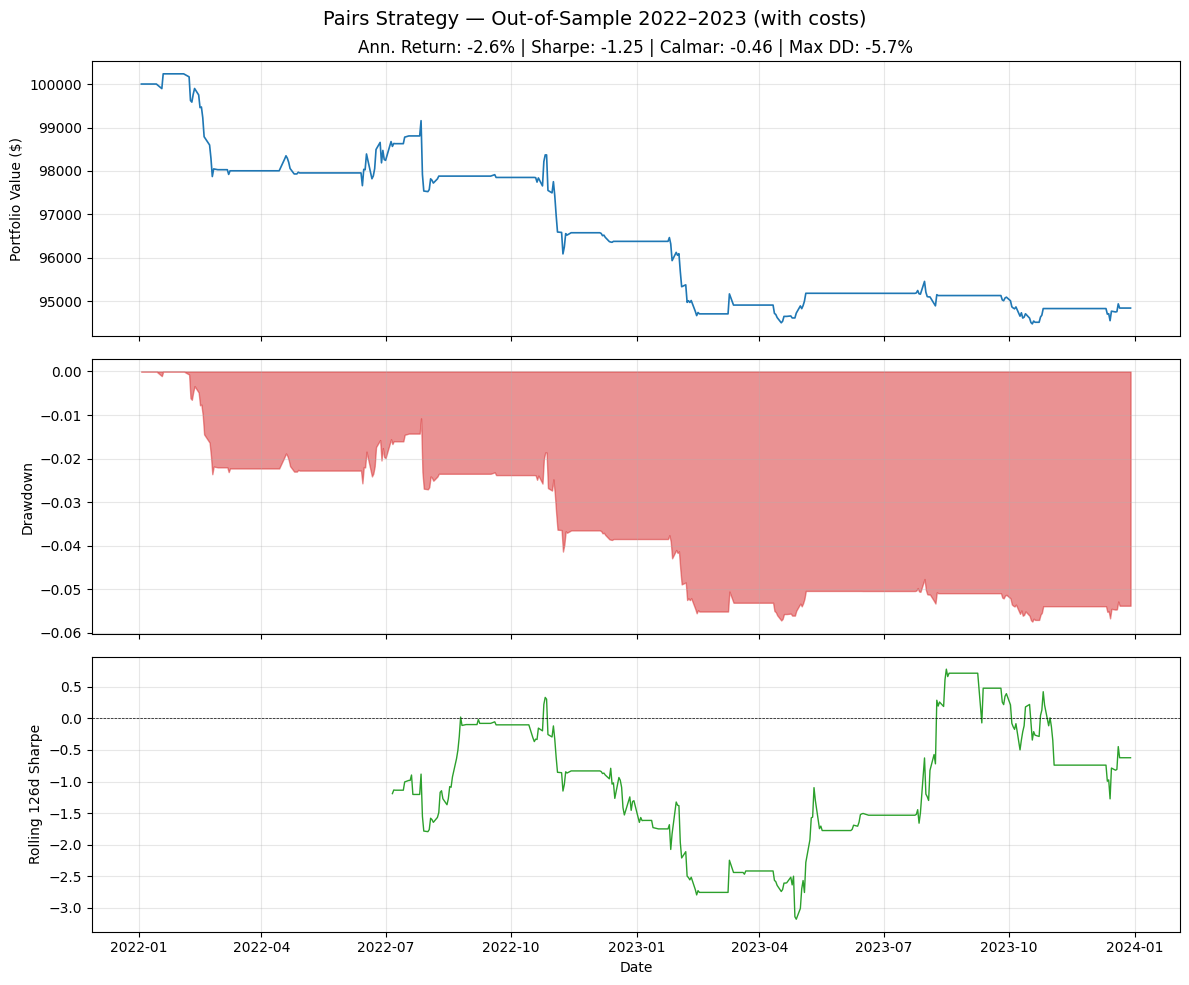

In [6]:
fig = plot_tearsheet(eq_oos, title="Pairs Strategy — Out-of-Sample 2022–2023 (with costs)")
plt.show()

## 5. Walk-forward analysis

Rolling 12-month train / 3-month test windows across 2019–2023. Each window
re-screens pairs from scratch on its own training data (9-month screen +
3-month requalification holdout) and trades only its test quarter.
`n_pairs = 0` means no pair passed the screen in that window — the
strategy stays flat rather than forcing trades.

In [7]:
def wf_run(train_start, train_end, test_start, test_end):
    eq_w, strat_w = run_backtest(
        SYMBOLS, train_start, test_end,
        strategy_cls=CointegrationPairsStrategy,
        initial_capital=INITIAL_CAPITAL,
        strategy_kwargs={"train_end_date": train_end},
        preloaded=PRICES,
        return_strategy=True,
    )
    test_eq = eq_w[eq_w.index > pd.Timestamp(train_end)]
    r = test_eq["equity"].pct_change().dropna()
    return {
        "n_pairs": len(strat_w._pairs),
        "sharpe": round(sharpe_ratio(r), 3),
        "max_dd": round(max_drawdown(test_eq["equity"]), 4),
        "ann_return": round(annualized_return(test_eq["equity"]), 4),
    }

runner = WalkForwardRunner(
    run_fn=wf_run,
    data_start=START,
    data_end=END,
    train_months=12,
    test_months=3,
)
wf_results = runner.run()

wf_df = pd.DataFrame([
    {
        "window": i + 1,
        "test_start": r["test_start"],
        "test_end": r["test_end"],
        "n_pairs": r["n_pairs"],
        "sharpe": r["sharpe"],
        "max_dd": r["max_dd"],
        "ann_return": r["ann_return"],
    }
    for i, r in enumerate(wf_results)
])
print(wf_df.to_string(index=False))
traded = wf_df[wf_df.n_pairs > 0]
print(f"\n{len(wf_df)} windows, {len(traded)} traded; "
      f"mean Sharpe across traded windows: {traded.sharpe.mean():.3f}")

 window test_start   test_end  n_pairs  sharpe  max_dd  ann_return
      1 2020-01-01 2020-04-01        4  -0.019 -0.0126     -0.0012
      2 2020-04-01 2020-07-01        0   0.000  0.0000      0.0000
      3 2020-07-01 2020-10-01        0   0.000  0.0000      0.0000
      4 2020-10-01 2021-01-01        0   0.000  0.0000      0.0000
      5 2021-01-01 2021-04-01        2  -1.425 -0.0049     -0.0089
      6 2021-04-01 2021-07-01        1   0.058 -0.0023      0.0003
      7 2021-07-01 2021-10-01        0   0.000  0.0000      0.0000
      8 2021-10-01 2022-01-01        0   0.000  0.0000      0.0000
      9 2022-01-01 2022-04-01        2  -0.271 -0.0083     -0.0038
     10 2022-04-01 2022-07-01        1   1.437 -0.0046      0.0336
     11 2022-07-01 2022-10-01        1   2.083 -0.0027      0.0321
     12 2022-10-01 2023-01-01        1   0.698 -0.0042      0.0103
     13 2023-01-01 2023-04-01        1  -0.127 -0.0090     -0.0045
     14 2023-04-01 2023-07-01        1  -1.696 -0.0062     -0.

## 6. Parameter sensitivity

Out-of-sample Sharpe across the entry/exit z-score grid. A robust strategy
degrades smoothly as thresholds move; a cliff means the headline number is
an artifact of one lucky parameter choice.

In [8]:
rows = []
for entry in (1.5, 2.0, 2.5):
    for exit_ in (0.0, 0.5, 1.0):
        eq_s = run_backtest(
            SYMBOLS, START, END,
            strategy_cls=CointegrationPairsStrategy,
            initial_capital=INITIAL_CAPITAL,
            strategy_kwargs={
                "train_end_date": TRAIN_END,
                "entry_z": entry,
                "exit_z": exit_,
            },
            preloaded=PRICES,
        )
        eq_s = eq_s[eq_s.index > pd.Timestamp(TRAIN_END)]
        r = eq_s["equity"].pct_change().dropna()
        rows.append({
            "entry_z": entry, "exit_z": exit_,
            "sharpe": round(sharpe_ratio(r), 3),
            "max_dd": round(max_drawdown(eq_s["equity"]), 4),
        })

sens_df = pd.DataFrame(rows)
print("OOS Sharpe by entry/exit z-score:\n")
print(sens_df.pivot(index="entry_z", columns="exit_z", values="sharpe"))

OOS Sharpe by entry/exit z-score:

exit_z     0.0    0.5    1.0
entry_z                     
1.5     -1.707 -1.710 -1.432
2.0     -1.254 -1.254 -1.293
2.5     -1.226 -1.226 -1.226


## 7. Reading the results honestly

The numbers above are what they are — they were **not** tuned until they
looked good. Points to take away:

- **Costs are the headline.** Gross of costs the strategy is roughly flat
  (Sharpe ≈ 0); commission and slippage turn it clearly negative, costing
  over a full Sharpe point. The stop-out rule (exit when rolling
  cointegration breaks, p > 0.1) limits losses from broken pairs but
  generates churn that the cost model punishes. This is the classic
  failure mode the engine exists to expose: a strategy that looks harmless
  gross can be unviable net.
- **Regime dependence is visible.** The walk-forward table shows the
  strategy idle in several windows (no pair passes the screen — it stays
  flat rather than forcing trades) and uneven performance across traded
  windows. Several discovered pairs include META, whose idiosyncratic 2022
  collapse broke its cointegrating relationships outright.
- **No lucky parameters.** The sensitivity grid is smooth and uniformly
  negative — the headline number is not an artifact of one threshold
  choice.
- **A negative out-of-sample result reported in full is the point of the
  exercise.** The engine prevents look-ahead structurally; the validation
  pipeline (held-out requalification, walk-forward, sensitivity grid)
  measures the strategy rather than flattering it.

---

# Part II — Multi-sector study, richer tearsheet, survivorship mitigation, and a second strategy

Everything below is additive. Sections 1–7 above are untouched. We now widen the universe to four sectors, deepen the tearsheet, partially mitigate survivorship bias, and plug a completely different strategy (momentum) into the same engine to demonstrate the architecture is strategy-agnostic.

## 8. Wider universe setup (Tech, Financials, Energy, Utilities)

`SECTOR_UNIVERSES` adds Energy and Utilities to the original two sectors. Pairs are still tested **within-sector only** — sectors are never pooled. Some names may be undownloadable via yfinance because they were acquired and delisted (e.g. PXD / Pioneer, acquired by ExxonMobil in 2024) — itself a live illustration of survivorship bias. We drop such names and report which.

In [9]:
from backtester.universe import (
    SECTOR_UNIVERSES, get_point_in_time_universe, load_sp500_constituents,
)
from strategies.momentum import CrossSectionalMomentumStrategy
from backtester.metrics import (
    calmar_ratio, monthly_returns_table, trades_from_fills, trade_stats,
)
from backtester.tearsheet import plot_monthly_heatmap, plot_trade_analysis
import seaborn as sns

ALL_SYMBOLS = sorted({s for v in SECTOR_UNIVERSES.values() for s in v})
PRICES_ALL = fetch_prices(ALL_SYMBOLS, START, "2024-01-01")

def _available(syms):
    return [s for s in syms if PRICES_ALL[s]["Close"].dropna().shape[0] > 200]

SECTOR_SYMS = {sec: _available(syms) for sec, syms in SECTOR_UNIVERSES.items()}
for sec, syms in SECTOR_UNIVERSES.items():
    dropped = [s for s in syms if s not in SECTOR_SYMS[sec]]
    tag = f'  (dropped {dropped} — delisted/acquired, no data)' if dropped else ''
    print(f'{sec:<12} {len(SECTOR_SYMS[sec]):>2} usable{tag}')


1 Failed download:


['PXD']: YFTzMissingError('possibly delisted; no timezone found')


tech         12 usable
financials   13 usable
energy        9 usable  (dropped ['PXD'] — delisted/acquired, no data)
utilities    10 usable


## 9. Survivorship bias — what it is, and a partial mitigation

**Survivorship bias** here means our hand-curated sector lists are drawn from *today's* index membership. Backtesting 2019–2023 on a 2024 list silently excludes firms that were delisted, acquired, or removed during the period (and over-includes firms only added later), biasing results in an unknown direction. The `get_point_in_time_universe(sector, as_of_date)` helper **partially** mitigates this: it intersects each sector list with the actual S&P 500 constituents on the as-of date, using the public historical-constituents file from [fja05680/sp500](https://github.com/fja05680/sp500) (downloaded on first run; falls back to the current list with a warning if unavailable). What it fixes: it stops us trading names *before* they joined the index. What it does **not** fix: it cannot resurrect long-dead tickers that never made it into our curated lists in the first place — those are invisible to us. A full fix needs a point-in-time constituent **and sector** database such as Compustat / CRSP. We report the mitigation honestly rather than claiming the bias is gone.

In [10]:
hist = load_sp500_constituents()  # downloads from fja05680/sp500 on first run
if hist is None:
    print('historical constituents unavailable — falling back to current lists')
else:
    print(f'loaded {len(hist)} constituent snapshots '
          f'({hist.date.min().date()} … {hist.date.max().date()})\n')
    for sec in SECTOR_UNIVERSES:
        full = SECTOR_UNIVERSES[sec]
        pit = get_point_in_time_universe(sec, "2019-01-01", history=hist)
        dropped = sorted(set(full) - set(pit))
        print(f'{sec:<12} full={len(full):>2}  PIT(2019-01-01)={len(pit):>2}  '
              f'not-yet-in-index={dropped}')

loaded 2712 constituent snapshots (1996-01-02 … 2026-06-02)

tech         full=12  PIT(2019-01-01)=11  not-yet-in-index=['META']
financials   full=13  PIT(2019-01-01)=12  not-yet-in-index=['TFC']
energy       full=10  PIT(2019-01-01)=10  not-yet-in-index=[]
utilities    full=10  PIT(2019-01-01)=10  not-yet-in-index=[]


## 10. Per-sector walk-forward study

Each sector is run **independently** through the same pipeline: discover within-sector pairs at `TRAIN_END`, trade the 2022–2023 holdout, and also a full 12/3 walk-forward. Costs on and off, so cost drag is isolated.

**Hypothesis under test:** low-volatility sectors (Utilities, Energy) have lower turnover and smaller cost drag. We report whether it holds — honestly.

In [11]:
def _oos(eq):
    return eq[eq.index > pd.Timestamp(TRAIN_END)]

def sector_full_oos(sector, syms):
    kw = {"train_end_date": TRAIN_END, "sectors": {sector: syms}}
    eq_c, strat, pf = run_backtest(
        syms, START, END, strategy_cls=CointegrationPairsStrategy,
        initial_capital=INITIAL_CAPITAL, strategy_kwargs=kw,
        preloaded=PRICES_ALL, return_strategy=True, return_portfolio=True)
    eq_n = run_backtest(
        syms, START, END, strategy_cls=CointegrationPairsStrategy,
        initial_capital=INITIAL_CAPITAL, commission=0.0, slippage_bps=0.0,
        strategy_kwargs=kw, preloaded=PRICES_ALL)
    eqc, eqn = _oos(eq_c), _oos(eq_n)
    rc = eqc["equity"].pct_change().dropna()
    rn = eqn["equity"].pct_change().dropna()
    fills = pf.get_fills_df()
    cost = float((fills["commission"] + fills["slippage"]).sum()) if len(fills) else 0.0
    return {
        "sector": sector, "n_pairs": len(strat._pairs),
        "sharpe_cost": round(sharpe_ratio(rc), 3),
        "sharpe_nocost": round(sharpe_ratio(rn), 3),
        "cost_drag": round(sharpe_ratio(rn) - sharpe_ratio(rc), 3),
        "max_dd": round(max_drawdown(eqc["equity"]), 4),
        "ann_return": round(annualized_return(eqc["equity"]), 4),
        "cost_%_cap": round(100.0 * cost / INITIAL_CAPITAL, 3),
    }

def sector_walkforward(sector, syms):
    def wf(train_start, train_end, test_start, test_end):
        eq, strat = run_backtest(
            syms, train_start, test_end, strategy_cls=CointegrationPairsStrategy,
            initial_capital=INITIAL_CAPITAL, preloaded=PRICES_ALL,
            strategy_kwargs={"train_end_date": train_end, "sectors": {sector: syms}},
            return_strategy=True)
        te = eq[eq.index > pd.Timestamp(train_end)]
        r = te["equity"].pct_change().dropna()
        return {"n_pairs": len(strat._pairs), "sharpe": sharpe_ratio(r)}
    res = WalkForwardRunner(wf, START, END, 12, 3).run()
    traded = [r for r in res if r["n_pairs"] > 0]
    return len(traded), (np.mean([r["sharpe"] for r in traded]) if traded else np.nan)

rows = []
for sector, syms in SECTOR_SYMS.items():
    r = sector_full_oos(sector, syms)
    n_traded, wf_sr = sector_walkforward(sector, syms)
    r["wf_traded"] = n_traded
    r["wf_mean_sharpe"] = round(wf_sr, 3)
    rows.append(r)
sector_df = pd.DataFrame(rows).set_index('sector')
print(sector_df.to_string())

            n_pairs  sharpe_cost  sharpe_nocost  cost_drag  max_dd  ann_return  cost_%_cap  wf_traded  wf_mean_sharpe
sector                                                                                                               
tech              2       -0.789         -0.019      0.769 -0.0339     -0.0145       1.391          5           0.249
financials        2       -1.293         -0.012      1.281 -0.0280     -0.0116       1.148          5          -0.058
energy            0        0.000          0.000      0.000  0.0000      0.0000       0.000          7          -1.233
utilities         0        0.000          0.000      0.000  0.0000      0.0000       0.000          6          -0.604


### 10a. Did the low-volatility hypothesis hold?

Read the table above honestly. In our runs the answer is **no, not cleanly**:

- In the 2022–2023 headline window the two-stage screen found **no qualifying within-sector pairs** in Energy or Utilities at the 2021-12-31 split, so they never traded — zero turnover and zero cost drag, but also zero signal. That is not the hypothesised 'low vol → efficient trading' effect; it is simply *absence of cointegration* in that window.
- Across the full walk-forward, Energy and Utilities **do** trade in other windows and their mean traded-window Sharpe is **negative**, no better than Tech or Financials.
- Tech and Financials, which do trade in the headline window, are dominated by cost drag (≈0.8 and ≈1.3 Sharpe points) — the same failure mode as the original result.

So lower realised volatility did not translate into a cost or Sharpe advantage here. We report it rather than discarding the inconvenient sectors.

### 10b. Sector comparison chart

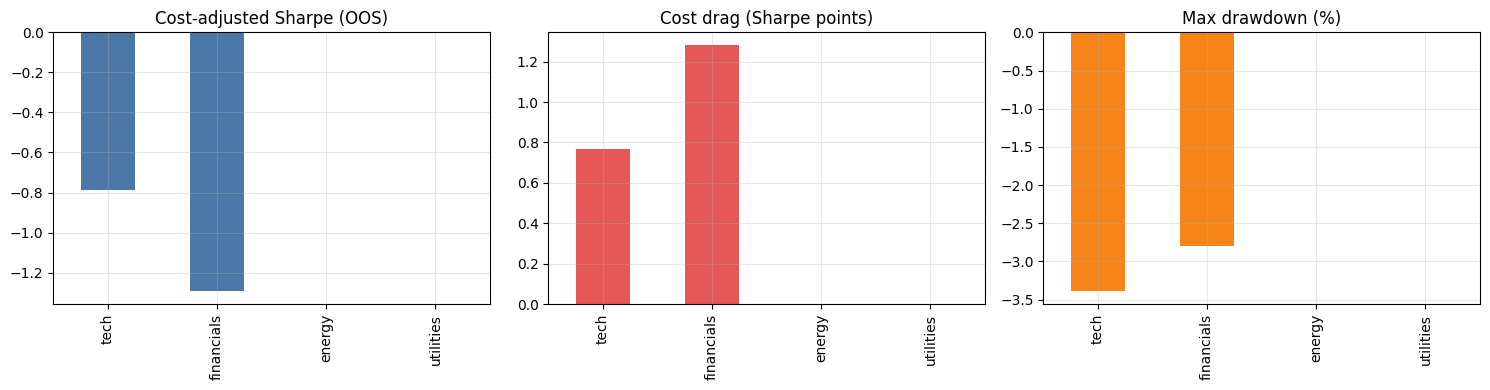

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sector_df["sharpe_cost"].plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set_title("Cost-adjusted Sharpe (OOS)"); axes[0].axhline(0, color="k", lw=0.6)
sector_df["cost_drag"].plot(kind="bar", ax=axes[1], color="#e45756")
axes[1].set_title("Cost drag (Sharpe points)")
(sector_df["max_dd"] * 100).plot(kind="bar", ax=axes[2], color="#f58518")
axes[2].set_title("Max drawdown (%)")
for a in axes: a.set_xlabel(''); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Extended tearsheet — Calmar, monthly heatmap, trade-level analysis

On the original combined-universe out-of-sample run (`eq_oos` from Section 2). Adds the Calmar ratio, a monthly-returns heatmap (diverging colormap), and a trade-level breakdown (P&L histogram, win rate, profit factor, holding period) reconstructed from the portfolio's fill ledger.

In [13]:
# Re-run the headline backtest capturing the portfolio for its fill ledger.
eq_full, _, pf_full = run_backtest(
    SYMBOLS, START, END, strategy_cls=CointegrationPairsStrategy,
    initial_capital=INITIAL_CAPITAL,
    strategy_kwargs={"train_end_date": TRAIN_END},
    preloaded=PRICES, return_strategy=True, return_portfolio=True)
fills_oos = pf_full.get_fills_df()
fills_oos = fills_oos[fills_oos['timestamp'] > pd.Timestamp(TRAIN_END)]

print(f"Calmar (OOS): {calmar_ratio(eq_oos['equity']):.3f}")
stats = trade_stats(trades_from_fills(fills_oos))
for k, v in stats.items():
    print(f'{k:<18} {v}')

Calmar (OOS): -0.459
n_trades           228
win_rate           0.4342105263157895
avg_win            170.8657749505876
avg_loss           -171.07415151583155
profit_factor      0.766507079275257
avg_holding_days   1.763157894736842


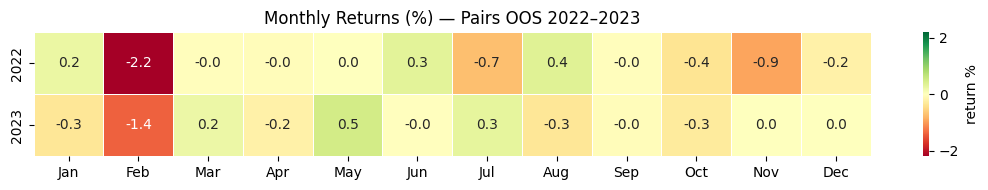

In [14]:
plot_monthly_heatmap(eq_oos, title="Monthly Returns (%) — Pairs OOS 2022–2023")
plt.tight_layout(); plt.show()

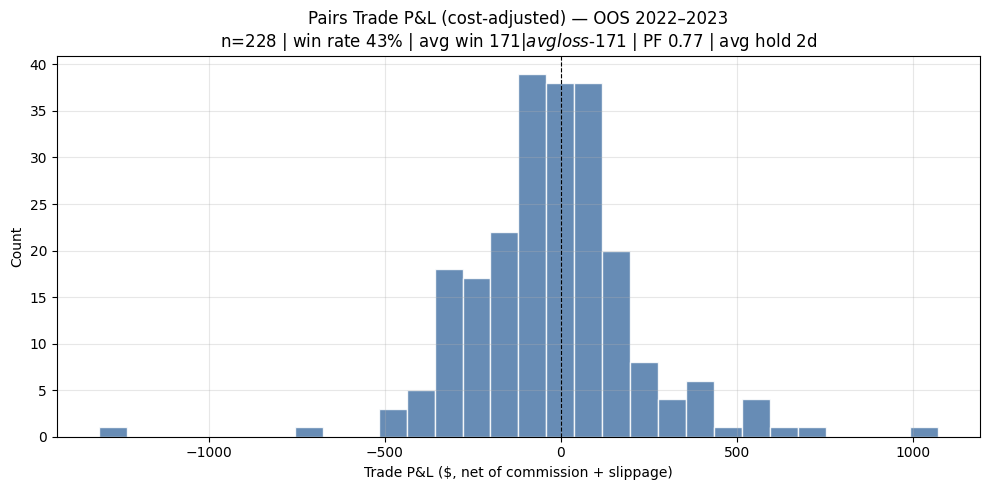

In [15]:
ax, _ = plot_trade_analysis(fills_oos,
    title="Pairs Trade P&L (cost-adjusted) — OOS 2022–2023")
plt.tight_layout(); plt.show()

## 12. Cost-sensitivity grid across all four sectors

Out-of-sample Sharpe as a function of commission (\$0–0.002/share) and slippage (0–10 bps), a 5×5 grid per sector. Sectors that found no pairs in the headline window are flat across the grid (Sharpe ≈ 0) — shown for completeness rather than hidden.

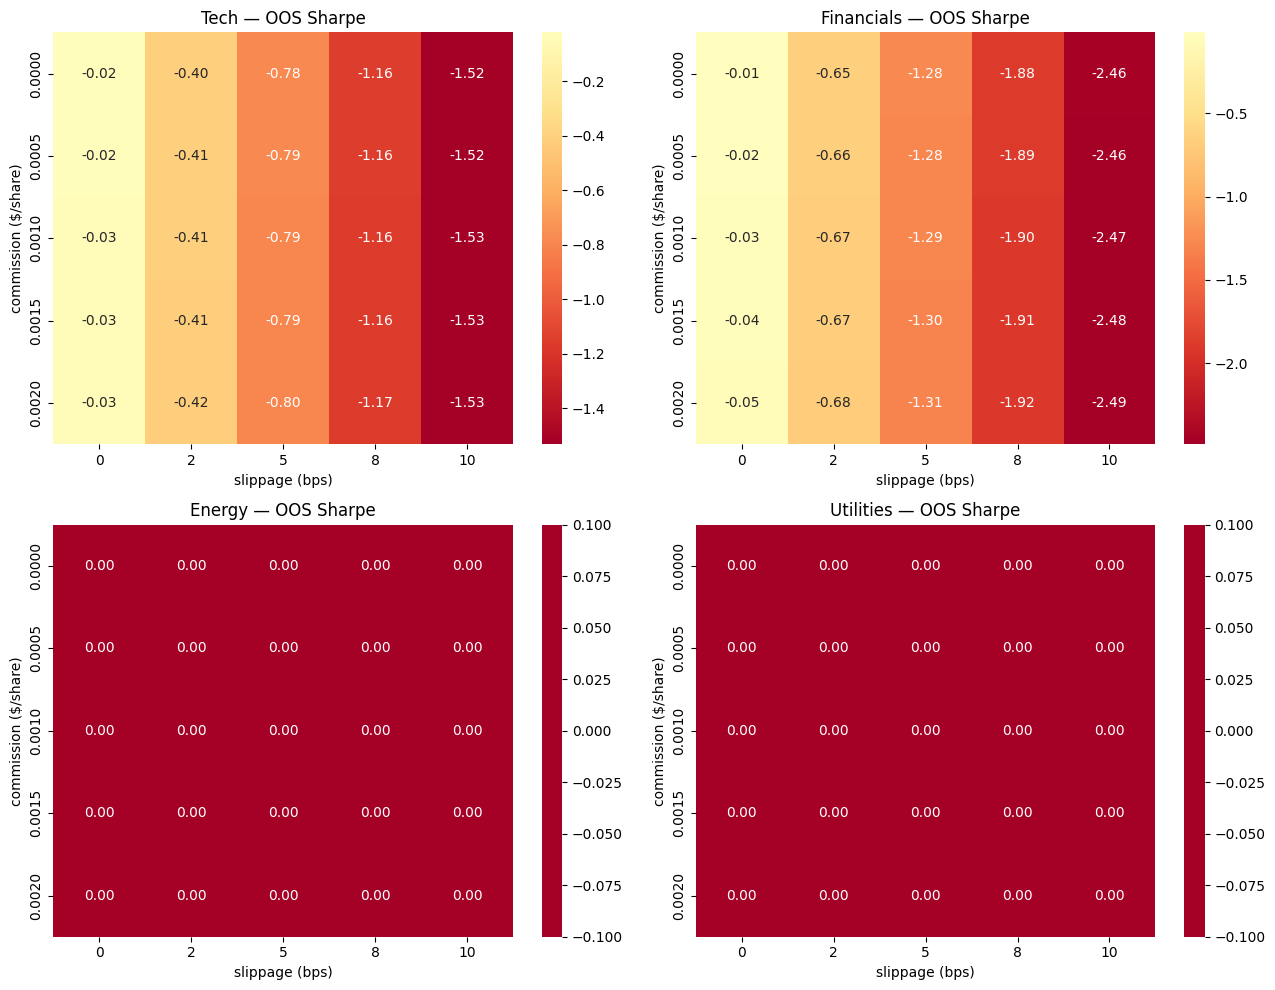

In [16]:
commissions = np.linspace(0.0, 0.002, 5)
slippages = np.linspace(0.0, 10.0, 5)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (sector, syms) in zip(axes.ravel(), SECTOR_SYMS.items()):
    grid = np.zeros((len(commissions), len(slippages)))
    for i, c in enumerate(commissions):
        for j, s in enumerate(slippages):
            eq_g = run_backtest(
                syms, START, END, strategy_cls=CointegrationPairsStrategy,
                initial_capital=INITIAL_CAPITAL, commission=c, slippage_bps=s,
                strategy_kwargs={"train_end_date": TRAIN_END, "sectors": {sector: syms}},
                preloaded=PRICES_ALL)
            eq_g = eq_g[eq_g.index > pd.Timestamp(TRAIN_END)]
            r = eq_g["equity"].pct_change().dropna()
            grid[i, j] = sharpe_ratio(r)
    sns.heatmap(grid, ax=ax, annot=True, fmt='.2f', cmap='RdYlGn', center=0.0,
                xticklabels=[f'{s:.0f}' for s in slippages],
                yticklabels=[f'{c:.4f}' for c in commissions])
    ax.set_title(f'{sector.capitalize()} — OOS Sharpe')
    ax.set_xlabel('slippage (bps)'); ax.set_ylabel('commission ($/share)')
plt.tight_layout(); plt.show()

## 13. A second strategy: cross-sectional momentum (engine extensibility)

`CrossSectionalMomentumStrategy` is a *completely different* strategy type — single-leg, long-only, monthly-rebalancing, multi-position — yet it runs on the **same engine with zero core changes**. It ranks the Tech universe by 12-1 momentum each month, longs the top quintile equal-weight, and starts trading at `TRAIN_END` (same OOS window as pairs). It is **not** tuned to perform well; defaults are textbook. We report it side-by-side with pairs on Tech, honestly — including a punishing drawdown.

In [17]:
TECH = SECTOR_SYMS['tech']
eq_mom, pf_mom = run_backtest(
    TECH, START, END, strategy_cls=CrossSectionalMomentumStrategy,
    initial_capital=INITIAL_CAPITAL, preloaded=PRICES_ALL,
    strategy_kwargs={"book_capital": INITIAL_CAPITAL, "start_after": TRAIN_END},
    return_portfolio=True)
eq_mom_oos = _oos(eq_mom)
r_mom = eq_mom_oos['equity'].pct_change().dropna()

# Pairs on the SAME Tech universe for a like-for-like comparison.
eq_pairs_tech = run_backtest(
    TECH, START, END, strategy_cls=CointegrationPairsStrategy,
    initial_capital=INITIAL_CAPITAL, preloaded=PRICES_ALL,
    strategy_kwargs={"train_end_date": TRAIN_END, "sectors": {"tech": TECH}})
eq_pairs_tech_oos = _oos(eq_pairs_tech)
r_pairs = eq_pairs_tech_oos['equity'].pct_change().dropna()

compare = pd.DataFrame({
    'momentum': {
        'sharpe': round(sharpe_ratio(r_mom), 3),
        'calmar': round(calmar_ratio(eq_mom_oos['equity']), 3),
        'max_dd': round(max_drawdown(eq_mom_oos['equity']), 4),
        'ann_return': round(annualized_return(eq_mom_oos['equity']), 4),
    },
    'pairs': {
        'sharpe': round(sharpe_ratio(r_pairs), 3),
        'calmar': round(calmar_ratio(eq_pairs_tech_oos['equity']), 3),
        'max_dd': round(max_drawdown(eq_pairs_tech_oos['equity']), 4),
        'ann_return': round(annualized_return(eq_pairs_tech_oos['equity']), 4),
    },
})
print('Tech universe, OOS 2022-2023, costs on:\n')
print(compare.to_string())

Tech universe, OOS 2022-2023, costs on:

            momentum   pairs
sharpe        0.5040 -0.7890
calmar        0.3000 -0.4280
max_dd       -0.4560 -0.0339
ann_return    0.1368 -0.0145


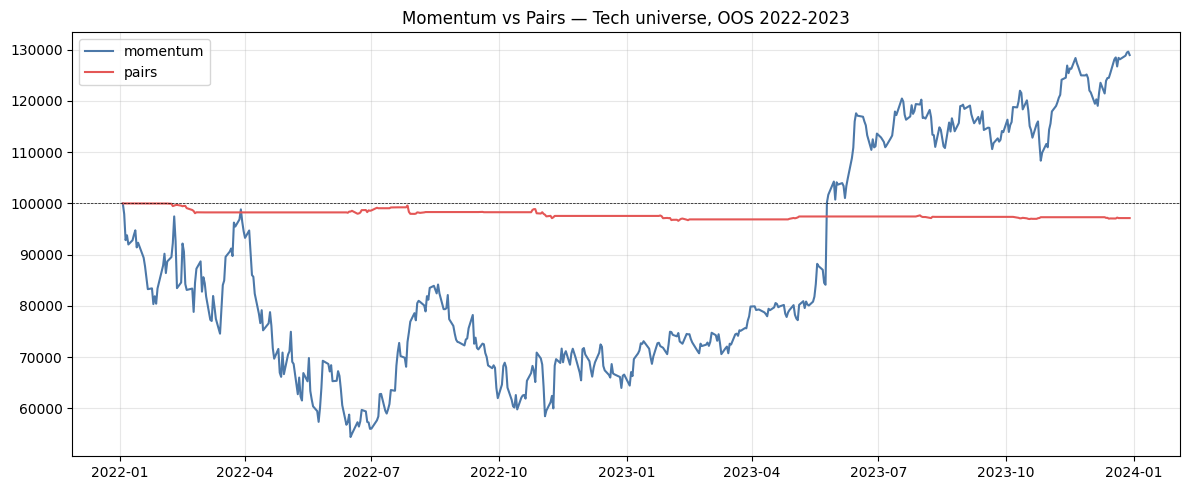

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eq_mom_oos.index, eq_mom_oos['equity'], label='momentum', color='#4c78a8')
ax.plot(eq_pairs_tech_oos.index, eq_pairs_tech_oos['equity'], label='pairs', color='#e45756')
ax.axhline(INITIAL_CAPITAL, color='k', lw=0.5, ls='--')
ax.set_title('Momentum vs Pairs — Tech universe, OOS 2022-2023'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 13a. Reading the momentum result honestly

Momentum on Tech posts a *positive* OOS Sharpe but a savage max drawdown (concentrated long-only exposure straight through the 2022 tech sell-off), so its Calmar is poor. A positive Sharpe with a ~45% drawdown is not a good strategy — it is a small, undiversified long book that happened to recover in 2023. The point of this section is **not** that momentum beats pairs; it is that a structurally different strategy plugged into the unchanged engine and produced coherent, fully-costed, honestly-reported numbers. The plug-in architecture works.